In [19]:
import os 
#Le module os en Python fait partie de la bibliothèque standard et fournit des fonctions pour interagir avec le système d'exploitation
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
#butter : crée les coefficients d’un filtre de Butterworth à partir de l’ordre du filtre, les fréquences de coupure, et le type ('low', 'high', 'band').Il retourne deux vecteurs de coefficients : b (numérateur), a (dénominateur).
#filtfilt : applique le filtre sans décalage de phase donc le signal reste temporellement fidèle.

# Filtrage: 
filtre passe-bande de Butterworth du 1er ordre (20,8–498,4 Hz) 

In [20]:
# -----------------------
# Paramètres du filtre
LOWCUT = 20.8  # Filtre passe-haut actif du 1er ordre, fc = 20,8 Hz
HIGHCUT = 498.4  # Filtre passe-bas actif du 1er ordre, fc = 498,4 Hz
FS = 1259.0  # fréquence d'échantillonnage
ORDER = 1  # filtre du 1er ordre
GAIN = 200  # Amplification MyoWare
# -----------------------

# Définir le filtre passe-bande Butterworth
def butter_bandpass(lowcut, highcut, fs, order=1):
    nyq = 0.5 * fs  # fréquence de Nyquist
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

# Appliquer amplification + filtre à un signal
def preprocess_signal(data, lowcut=LOWCUT, highcut=HIGHCUT, fs=FS, order=ORDER, gain=GAIN):
    data_amplified = data * gain
    b, a = butter_bandpass(lowcut, highcut, fs, order)
    return filtfilt(b, a, data_amplified)


Rappel
 La fréquence de Nyquist indique la fréquence maximale qu’un signal peut avoir pour être correctement représenté après échantillonnage sans aliasing.
 L’aliasing est une erreur qui survient lorsqu'on échantillonne un signal trop rapidement ou avec une fréquence trop basse comparé aux fréquences présentent dans le signal. Les hautes fréquences se replient et apparaissent comme de fausses basses fréquences dans ton signal.

In [3]:
# Base directory
base_dir = "./dataset/sEMG_data/sEMG_data"

for i in range(1, 14):
    subject = f"subject_{i}"
    input_dir = os.path.join(base_dir, subject, subject)

    # === Traitement des fichiers trials ===
    output_dir = os.path.join(input_dir, "filtred")
    os.makedirs(output_dir, exist_ok=True)

    for root, dirs, files in os.walk(input_dir):
        if "filtred" in root or "MVC" in root:
            continue  # Ignore filtred et MVC ici

        for file in files:
            if file.endswith(".csv"):
                input_path = os.path.join(root, file)
                df = pd.read_csv(input_path)

                time_col = df.columns[0]
                emg_cols = [col for col in df.columns if "EMG" in col]

                filtered_df = pd.DataFrame()
                filtered_df[time_col] = df[time_col]

                for col in emg_cols:
                    filtered_df[col] = preprocess_signal(df[col].values)

                relative_path = os.path.relpath(root, input_dir)
                output_subdir = os.path.join(output_dir, relative_path)
                os.makedirs(output_subdir, exist_ok=True)
                output_path = os.path.join(output_subdir, file).replace("\\", "/")

                filtered_df.to_csv(output_path, index=False)
                print(f"[{subject}] Trial filtré sauvegardé : {output_path}")

    # === Traitement des fichiers MVC ===
    mvc_input_dir = os.path.join(input_dir, "MVC")
    mvc_output_dir = os.path.join(mvc_input_dir, "filtred")
    os.makedirs(mvc_output_dir, exist_ok=True)

    if os.path.exists(mvc_input_dir):
        for file in os.listdir(mvc_input_dir):
            if file.endswith(".csv"):
                input_path = os.path.join(mvc_input_dir, file)
                df = pd.read_csv(input_path)

                time_col = df.columns[0]
                emg_cols = [col for col in df.columns if "EMG" in col and "filter" not in col]

                if not emg_cols:
                    print(f"[{subject}] ❗ Aucune colonne EMG brute dans {file}")
                    continue

                filtered_df = pd.DataFrame()
                filtered_df[time_col] = df[time_col]
                for col in emg_cols:
                    filtered_df[col] = preprocess_signal(df[col].values)

                output_path = os.path.join(mvc_output_dir, file).replace("\\", "/")
                filtered_df.to_csv(output_path, index=False)
                print(f"[{subject}] MVC filtré sauvegardé : {output_path}")

[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_1.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_10.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_11.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_12.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_2.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_3.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_4.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_5.csv
[subject_1] Trial filtré sauvegardé : ./dataset/sEMG_data/sEMG_data/subject_1/subject_1/filtred/./trial_6.csv
[subjec

Segmentation:
découpage en fenêtres de 4 secondes avec chevauchement de 50 % 

In [21]:
# Paramètres
window_sec = 4
step_sec = 2

def sliding_window(signal, window_size_sec= window_sec, step_size_sec=step_sec, sampling_rate=FS ):
    window_size = int(window_size_sec * sampling_rate)
    step_size = int(step_size_sec * sampling_rate)
    
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        end = start + window_size
        windows.append(signal[start:end])
        
    return windows

Extraction de caractéristiques:

In [22]:
from scipy.fft import fft, fftfreq
#fft – Fast Fourier Transform
#fft(signal): produit un vecteur de valeurs complexes → les amplitudes des composantes fréquentielles
#fftfreq(N, 1/fs): donne les fréquences associées à chaque valeur dans fft

def extract_emg_features(window, sampling_rate=FS):
    N = len(window)

    # RMS
    rms = np.sqrt(np.mean(window**2))

    # MAV
    mav = np.mean(np.abs(window))

    # ZC (Zero Crossing, seuil bas pour éviter bruit)
    zc = np.sum(np.diff(np.sign(window)) != 0)

    # WL (Waveform Length)
    wl = np.sum(np.abs(np.diff(window)))

    # FFT
    freqs = fftfreq(N, 1 / sampling_rate)
    fft_vals = np.abs(fft(window))
    pos_mask = freqs >= 0
    power = fft_vals[pos_mask] ** 2
    freqs = freqs[pos_mask]

    # MNF (Mean Frequency)
    mnf = np.sum(freqs * power) / np.sum(power)

    # MDF (Median Frequency)
    cumulative_power = np.cumsum(power)
    mdf = freqs[np.searchsorted(cumulative_power, cumulative_power[-1] / 2)]

    return rms, mav, zc, wl, mdf, mnf


In [6]:
# Base du dataset
base_dir = "./dataset/sEMG_data/sEMG_data"

for i in range(1, 14):
    subject = f"subject_{i}"
    trial_dir = os.path.join(base_dir, subject, subject, "filtred")
    output_dir = os.path.join(base_dir, subject, subject, "features")
    os.makedirs(output_dir, exist_ok=True)

    for root, dirs, files in os.walk(trial_dir):
        if "MVC" in root:
            continue  # On ignore les MVC

        for file in files:
            if file.endswith(".csv"):
                df = pd.read_csv(os.path.join(root, file))
                time_col = df.columns[0]
                emg_cols = [col for col in df.columns if "EMG" in col]

                features_all = []

                for col in emg_cols:
                    windows = sliding_window(df[col].values, window_sec, step_sec, FS)
                    for idx, w in enumerate(windows):
                        rms, mav, zc, wl, mdf, mnf = extract_emg_features(w, FS)
                        features_all.append({
                            "subject": subject,
                            "file": file,
                            "muscle": col,
                            "window": idx,
                            "RMS": rms,
                            "MAV": mav,
                            "ZC": zc,
                            "WL": wl,
                            "MDF": mdf,
                            "MNF": mnf
                        })

                out_df = pd.DataFrame(features_all)
                out_name = os.path.splitext(file)[0] + "_features.csv"
                out_path = os.path.join(output_dir, out_name)
                out_df.to_csv(out_path, index=False)
                print(f"[{subject}] Fichier de caractéristiques sauvegardé : {out_path}")


[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_1_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_10_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_11_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_12_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_2_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_3_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\trial_4_features.csv
[subject_1] Fichier de caractéristiques sauvegardé : ./dataset/sEM

On ne garde que le muscle actif pour chaque trial

In [7]:
# Mapping trial -> agonist muscle
trial_to_muscle = {
    1: "R DELTOID ANTERIOR",
    2: "L DELTOID ANTERIOR",
    3: "R DELTOID POSTERIOR",
    4: "L DELTOID POSTERIOR",
    5: "R BICEPS BRACHII",
    6: "L BICEPS BRACHII",
    7: "R DELTOID MEDIUS",
    8: "L DELTOID MEDIUS",
    9: "R DELTOID ANTERIOR",
    10: "L DELTOID ANTERIOR",
    11: "R DELTOID POSTERIOR",
    12: "L DELTOID POSTERIOR"
}

# Dossier où se trouvent les fichiers de features
base_feature_dir = "./dataset/sEMG_data/sEMG_data"

for i in range(1, 14):
    subject = f"subject_{i}"
    features_dir = os.path.join(base_feature_dir, subject, subject, "features")

    if not os.path.exists(features_dir):
        continue

    for file in os.listdir(features_dir):
        if file.endswith("_features.csv"):
            file_path = os.path.join(features_dir, file)

            # Extraire le numéro de trial depuis le nom du fichier
            try:
                trial_num = int(file.split("_")[1].replace("trial", ""))
            except:
                continue  # nom de fichier inattendu

            target_muscle = trial_to_muscle.get(trial_num)
            if not target_muscle:
                continue

            df = pd.read_csv(file_path)
            
            # Filtrer uniquement la colonne muscle ciblé
            df_filtered = df[df["muscle"].str.contains(target_muscle)]

            if df_filtered.empty:
                print(f" Pas de données pour muscle ciblé {target_muscle} dans {file}")
                continue

            # Créer le nouveau nom de fichier
            clean_trial = f"trial{trial_num}"
            clean_muscle = target_muscle.replace(" ", "_")
            output_filename = f"{clean_muscle}_{clean_trial}_features.csv"
            output_path = os.path.join(features_dir, output_filename)


            df_filtered.to_csv(output_path, index=False)
            print(f"[{subject}] Fichier filtré enregistré : {output_path}")


[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\L_DELTOID_ANTERIOR_trial10_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\R_DELTOID_POSTERIOR_trial11_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\L_DELTOID_POSTERIOR_trial12_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\R_DELTOID_ANTERIOR_trial1_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\L_DELTOID_ANTERIOR_trial2_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\R_DELTOID_POSTERIOR_trial3_features.csv
[subject_1] Fichier filtré enregistré : ./dataset/sEMG_data/sEMG_data\subject_1\subject_1\features\L_DELTOID_POSTERIOR_trial4_features.csv
[subject_1] Fichier filtré 

Alignement avec les états de fatigue:

In [8]:
base_dir = "./dataset"
feature_base = os.path.join(base_dir, "sEMG_data", "sEMG_data")
fatigue_base = os.path.join(base_dir, "self_perceived_fatigue_index")

for i in range(1, 14):
    subject = f"subject_{i}"
    features_dir = os.path.join(feature_base, subject, subject, "features")
    fatigue_dir = os.path.join(fatigue_base, subject, subject)
    base_output_dir = os.path.join(feature_base, subject, subject, "labeled")

    if not os.path.exists(features_dir):
        continue

    for file in os.listdir(features_dir):
        if file.endswith("_features.csv") and (file.startswith("R_") or file.startswith("L_")):
            features_path = os.path.join(features_dir, file)
            trial_num = ''.join([c for c in file if c.isdigit()])
            fatigue_file = os.path.join(fatigue_dir, f"Trial_{trial_num}.csv")
            if not os.path.exists(fatigue_file):
                continue

            df_feat = pd.read_csv(features_path)
            df_fatigue = pd.read_csv(fatigue_file)

            df_feat["t_center"] = df_feat["window"] * step_sec + (window_sec / 2)
            df_feat["fatigue_label"] = df_feat["t_center"].apply(
                lambda t: df_fatigue.iloc[(df_fatigue["time"] - t).abs().argmin()]["label"]
            )

            muscle_name = file.split("_trial")[0]
            output_dir = os.path.join(base_output_dir, muscle_name)
            os.makedirs(output_dir, exist_ok=True)

            output_file = file.replace("_features.csv", "_labeled.csv")
            output_path = os.path.join(output_dir, output_file)
            df_feat.to_csv(output_path, index=False)
            print(f"[{subject}] Labeled file saved: {output_path}")


[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_BICEPS_BRACHII\L_BICEPS_BRACHII_trial6_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_DELTOID_ANTERIOR\L_DELTOID_ANTERIOR_trial10_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_DELTOID_ANTERIOR\L_DELTOID_ANTERIOR_trial2_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_DELTOID_MEDIUS\L_DELTOID_MEDIUS_trial8_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_DELTOID_POSTERIOR\L_DELTOID_POSTERIOR_trial12_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\L_DELTOID_POSTERIOR\L_DELTOID_POSTERIOR_trial4_labeled.csv
[subject_1] Labeled file saved: ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\labeled\R_BICEPS_BRACHII\R_BICEPS_BRAC

Entraînement d'un modèle qui prévoit la durée d'entraînement restante pour chaque participant en fonction de ses performances passées (entre t0 et l’instant T)
time step = 1 fenêtre de 4 secondes (5036 points)


In [ ]:
Pour chaque participant, pour chaque biceps, et pour chaque timestamp on calcule la durée restante comme t_fin - t_center avec t_fin = max(t_center) + 2 et la durée écoulée. On renvoie un fichier time labeled par muscle

In [23]:
# Chemin de base
base_dir = "./dataset"
feature_base = os.path.join(base_dir, "sEMG_data", "sEMG_data")

# Parcours des sujets
for i in range(1, 14):
    subject = f"subject_{i}"
    labeled_base = os.path.join(feature_base, subject, subject, "labeled")
    time_labeled_base = os.path.join(feature_base, subject, subject, "time_labeled")

    if not os.path.exists(labeled_base):
        continue

    for muscle in ["L_BICEPS_BRACHII", "R_BICEPS_BRACHII"]:
        muscle_input_dir = os.path.join(labeled_base, muscle)
        muscle_output_dir = os.path.join(time_labeled_base, muscle)

        if not os.path.exists(muscle_input_dir):
            continue

        os.makedirs(muscle_output_dir, exist_ok=True)

        for file in os.listdir(muscle_input_dir):
            if file.endswith("_labeled.csv"):
                file_path = os.path.join(muscle_input_dir, file)

                df = pd.read_csv(file_path)

                if "t_center" not in df.columns:
                    print(f"[{subject}] Fichier sans t_center : {file}")
                    continue

                # Calcul de t_fin
                t_fin = df["t_center"].max() + 2.0

                # Ajout de la colonne durée restante
                df["duration_remaining"] = t_fin - df["t_center"]
                df["duration_since_start"] = df["t_center"]

                # Sauvegarde dans le dossier time_labeled
                output_path = os.path.join(muscle_output_dir, file)
                df.to_csv(output_path, index=False)

                print(f"[{subject}] Sauvegardé dans : {output_path}")


[subject_1] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\time_labeled\L_BICEPS_BRACHII\L_BICEPS_BRACHII_trial6_labeled.csv
[subject_1] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_1\subject_1\time_labeled\R_BICEPS_BRACHII\R_BICEPS_BRACHII_trial5_labeled.csv
[subject_2] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_2\subject_2\time_labeled\L_BICEPS_BRACHII\L_BICEPS_BRACHII_trial6_labeled.csv
[subject_2] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_2\subject_2\time_labeled\R_BICEPS_BRACHII\R_BICEPS_BRACHII_trial5_labeled.csv
[subject_3] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_3\subject_3\time_labeled\L_BICEPS_BRACHII\L_BICEPS_BRACHII_trial6_labeled.csv
[subject_3] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_3\subject_3\time_labeled\R_BICEPS_BRACHII\R_BICEPS_BRACHII_trial5_labeled.csv
[subject_4] Sauvegardé dans : ./dataset\sEMG_data\sEMG_data\subject_4\subject_4\time_labeled\L_BICEPS_BRACHII\L_BICEPS_BRACH

découpage des données en séquences de cinq lignes pour chaque sujet

In [24]:
# Paramètres
base_dir = "./dataset/sEMG_data/sEMG_data"
features_list = ["RMS", "MAV", "ZC", "WL", "MDF", "MNF", "fatigue_label", "duration_since_start"]
target_col = "duration_remaining"
n_steps = 5

X_all = []
y_all = []

# Parcours de tous les fichiers time_labeled
for i in range(1, 14):
    subject = f"subject_{i}"
    time_labeled_base = os.path.join(base_dir, subject, subject, "time_labeled")

    for muscle in ["L_BICEPS_BRACHII", "R_BICEPS_BRACHII"]:
        muscle_dir = os.path.join(time_labeled_base, muscle)
        if not os.path.exists(muscle_dir):
            continue

        for file in os.listdir(muscle_dir):
            if file.endswith(".csv"):
                file_path = os.path.join(muscle_dir, file)
                try:
                    df = pd.read_csv(file_path)

                    if not all(col in df.columns for col in features_list + [target_col]):
                        print(f" Colonnes manquantes dans {file_path}")
                        continue

                    df = df[features_list + [target_col]].dropna().reset_index(drop=True)

                    # Création des séquences glissantes
                    for j in range(len(df) - n_steps + 1):
                        X_seq = df.loc[j:j+n_steps-1, features_list].values
                        y_seq = df.loc[j+n_steps-1, target_col]
                        X_all.append(X_seq)
                        y_all.append(y_seq)

                except Exception as e:
                    print(f" Erreur dans {file_path} : {e}")

# Conversion en tableau NumPy
X_array = np.array(X_all) 
y_array = np.array(y_all)  

print(f" Données préparées : {X_array.shape[0]} séquences, shape = {X_array.shape}")


 Données préparées : 3384 séquences, shape = (3384, 5, 8)


Normalisation des données 

In [25]:
from sklearn.preprocessing import StandardScaler #sklearn est une bibliothèque Python très populaire pour le machine learning classique
from sklearn.model_selection import train_test_split

#  Normalisation de X_array
n_samples, n_steps, n_features = X_array.shape #or sklearn s'attend à des tableaux en 2D
X_flat = X_array.reshape(-1, n_features)

scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)

X_array_scaled = X_flat_scaled.reshape(n_samples, n_steps, n_features)

#Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_array_scaled, y_array, test_size=0.2, random_state=42
)

Utilisation d'un modèle LSTM pour prédire la durée d'exercice 

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Définition du modèle
model = Sequential()
model.add(LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2]), unroll=True))
model.add(Dropout(0.3))
model.add(Dense(1))  # Sortie scalaire pour la régression

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Entraînement
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1500,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/1500
43/43 [==============================] - 2s 12ms/step - loss: 31128.0449 - val_loss: 28535.5664
Epoch 2/1500
43/43 [==============================] - 0s 5ms/step - loss: 30383.6562 - val_loss: 27365.0605
Epoch 3/1500
43/43 [==============================] - 0s 5ms/step - loss: 29003.5352 - val_loss: 26039.2109
Epoch 4/1500
43/43 [==============================] - 0s 5ms/step - loss: 27785.4395 - val_loss: 25250.8887
Epoch 5/1500
43/43 [==============================] - 0s 5ms/step - loss: 27168.6777 - val_loss: 24744.8809
Epoch 6/1500
43/43 [==============================] - 0s 4ms/step - loss: 26654.9277 - val_loss: 24303.8281
Epoch 7/1500
43/43 [==============================] - 0s 5ms/step - loss: 26207.7871 - val_loss: 23895.7793
Epoch 8/1500
43/43 [==============================] - 0s 4ms/step - loss: 25787.8867 - val_loss: 23505.9375
Epoch 9/1500
43/43 [==============================] - 0s 6ms/step - loss: 25394.8691 - val_loss: 23134.1016
Epoch 10/1500
43/43 [======

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prédictions
y_pred = model.predict(X_test).squeeze()
y_true = y_test.squeeze()

# Évaluation
print(f"MAE : {mean_absolute_error(y_true, y_pred):.2f} s")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} s")
print(f"R² : {r2_score(y_true, y_pred):.2f}")


22/22 [==============================] - 0s 2ms/step
MAE : 18.62 s
RMSE : 30.47 s
R² : 0.90


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prédictions
y_pred_train = model.predict(X_train).squeeze()
y_true_train = y_train.squeeze()

# Évaluation
print(f"MAE : {mean_absolute_error(y_true_train, y_pred_train):.2f} s")
print(f"RMSE : {np.sqrt(mean_squared_error(y_true_train, y_pred_train)):.2f} s")
print(f"R² : {r2_score(y_true_train, y_pred_train):.2f}")


85/85 [==============================] - 0s 2ms/step
MAE : 14.41 s
RMSE : 22.18 s
R² : 0.95


Sur une durée moyenne d'exercice de 4 minutes et 31 secondes

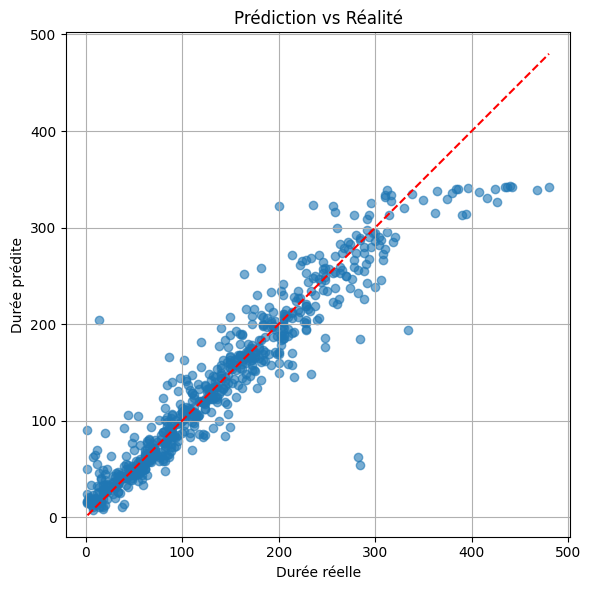

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# S'assurer que les données sont des vecteurs 1D
y_pred = np.squeeze(y_pred)
y_true = np.squeeze(y_test)

# Tracer la prédiction vs la réalité
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
plt.xlabel("Durée réelle")
plt.ylabel("Durée prédite")
plt.title("Prédiction vs Réalité")
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

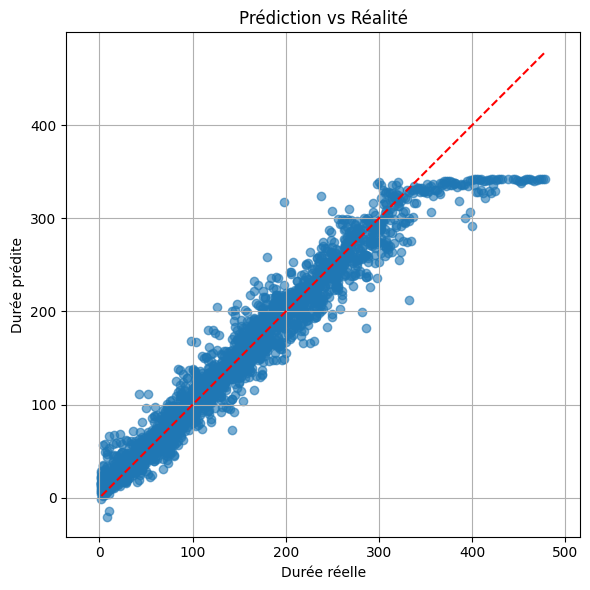

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# S'assurer que les données sont des vecteurs 1D
y_pred_train = np.squeeze(y_pred_train)
y_true_train = np.squeeze(y_train)

# Tracer la prédiction vs la réalité
plt.figure(figsize=(6, 6))
plt.scatter(y_true_train, y_pred_train, alpha=0.6)
plt.plot([y_true_train.min(), y_true_train.max()], [y_true_train.min(), y_true_train.max()], 'r--')
plt.xlabel("Durée réelle")
plt.ylabel("Durée prédite")
plt.title("Prédiction vs Réalité")
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [31]:
import tensorflow as tf

# Export du modèle entraîné au format .tflite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Sauvegarde dans un fichier
with open("Model_LSTM_Keras.tflite", "wb") as f:
    f.write(tflite_model)

print("Modèle exporté sous Model_LSTM_Keras.tflite")


INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmpzv6kmpl4\assets


INFO:tensorflow:Assets written to: C:\Users\ADMINI~1\AppData\Local\Temp\tmpzv6kmpl4\assets


Modèle exporté sous Model_LSTM_Keras.tflite
